In [ ]:
import pandas as pd
import os
import numpy as np
import pickle, json
import sys
sys.path.append("..")
import Modules
sim_dir = "/home/drfrbc/Neural-Modeling/simulations/2025-10-22-14-15-Testing_IncreaseTuftInh/allinh_delay_shift_4ms_Np5000"
synapses = pd.read_csv(os.path.join(sim_dir, "synapses.csv"))

--No graphics will be displayed.


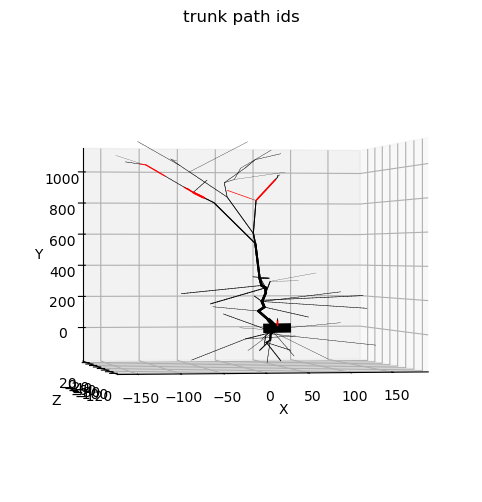

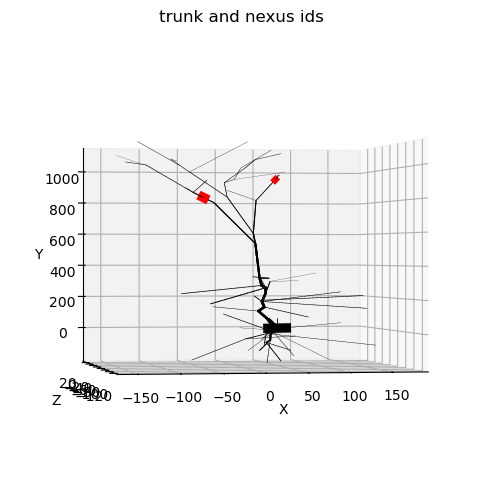

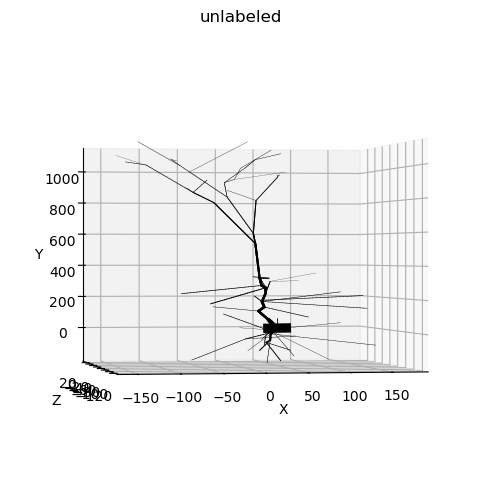

Plotting tuft:
sec_type: tuft
present sec_types in seg_data['sec_type_precise']: ['soma' 'perisomatic' 'distal_basal' 'oblique' 'nexus' 'tuft' 'trunk'
 'axon']


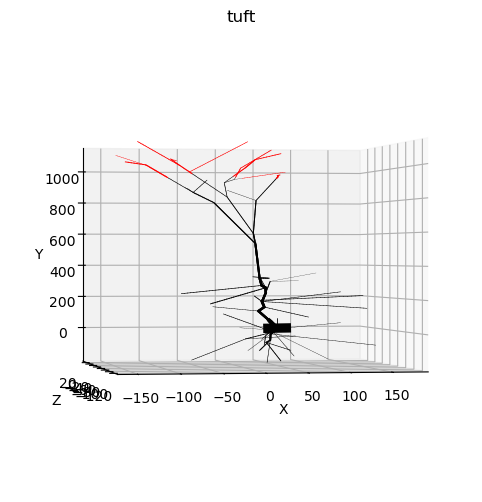

Plotting nexus:
sec_type: nexus
present sec_types in seg_data['sec_type_precise']: ['soma' 'perisomatic' 'distal_basal' 'oblique' 'nexus' 'tuft' 'trunk'
 'axon']


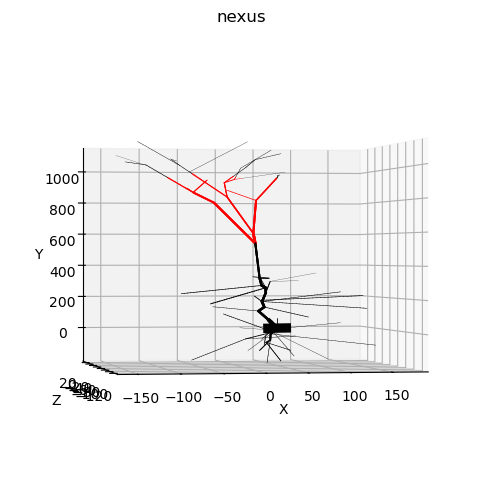

Plotting trunk:
sec_type: trunk
present sec_types in seg_data['sec_type_precise']: ['soma' 'perisomatic' 'distal_basal' 'oblique' 'nexus' 'tuft' 'trunk'
 'axon']


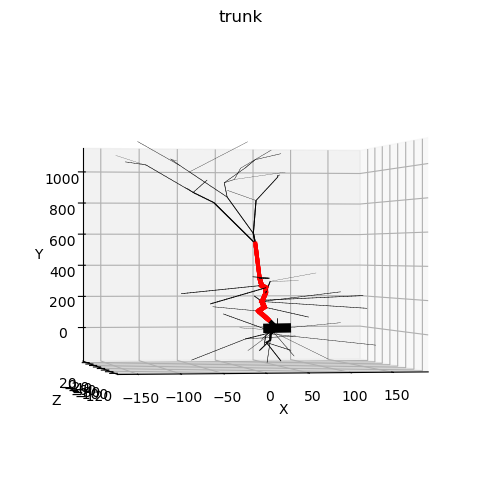

Plotting oblique:
sec_type: oblique
present sec_types in seg_data['sec_type_precise']: ['soma' 'perisomatic' 'distal_basal' 'oblique' 'nexus' 'tuft' 'trunk'
 'axon']


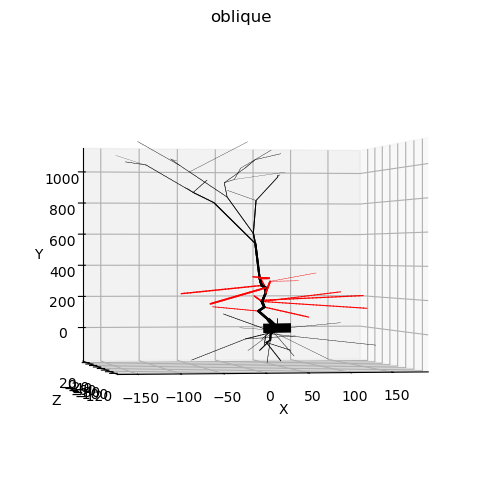

Plotting distal_basal:
sec_type: distal_basal
present sec_types in seg_data['sec_type_precise']: ['soma' 'perisomatic' 'distal_basal' 'oblique' 'nexus' 'tuft' 'trunk'
 'axon']


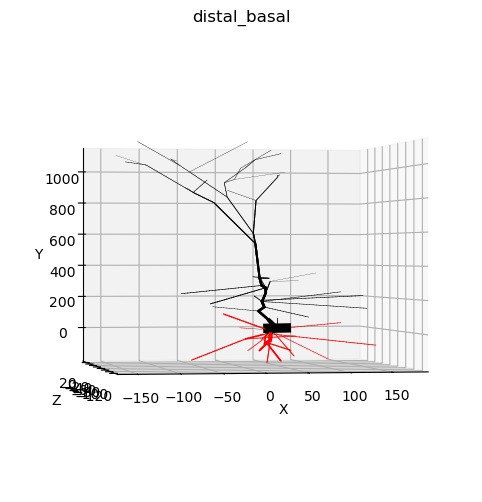

Plotting perisomatic:
sec_type: perisomatic
present sec_types in seg_data['sec_type_precise']: ['soma' 'perisomatic' 'distal_basal' 'oblique' 'nexus' 'tuft' 'trunk'
 'axon']


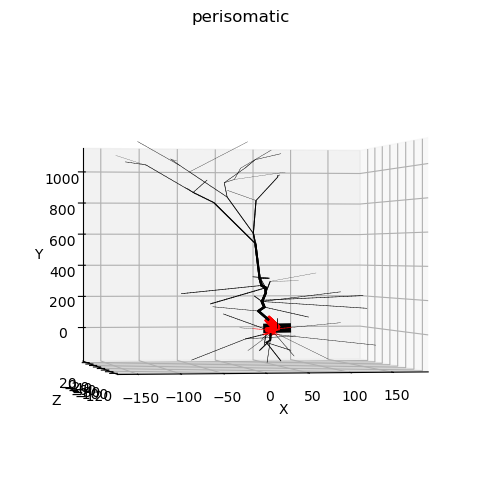

In [1]:
import sys
sys.path.append("..")
from Modules.plot_morphology import plot_morphology_flex, plot_reduced_morphology
from Modules import analysis
import pandas as pd
import os
sim_dir = "/home/drfrbc/Neural-Modeling/simulations/2025-11-03-12-34-lower_soma_spikes_increase_ca_spikes/sta_Complex_NexInhDen0_SomInhDen0.44_Np5000"
sim_dir = "/home/drfrbc/Neural-Modeling/simulations/2025-11-11-15-49-test_reduction/sta_Complex_Np5000" # fixes to connectivity
# sim_dir = "/home/drfrbc/Neural-Modeling/simulations/2025-10-29-17-44-testing_allen/sta_Complex_Np5000" # Allen
# sim_dir = "/home/drfrbc/Neural-Modeling/simulations/2025-10-30-11-18-tuning_tuft_raise_esyn/sta_Complex_TL23Den0.62_TL5Den0.31_TuftDistDen8.5_Np5000" # hay full

# Highlight all section typeS (keys of parameters.inh_syn_properties), each in its own plot. (USEFUL FOR DEBUGGING)
seg_data = pd.read_csv(os.path.join(sim_dir, "segment_data.csv"))
parameters = analysis.DataReader.load_parameters(sim_dir) # load parameters
figs, axs = plot_morphology_flex(
    seg_data,
    option='each_sec_type',
    parameters=parameters,
    out_dir='plots/morphology'
)

# trunk_ids = [1243, 1244, 1245, 1246, 1247, 1248, 1249, 1250, 1251, 1252, 1253, 1254, 1255,
#              1256, 1257, 1258, 1259, 1260, 1261, 1262, 1263, 1279, 1280, 1281, 1282, 1283, 
#              1284, 1285, 1286, 1287, 1288, 1289, 1290, 1291, 1292, 1293, 1294, 1295, 1307,
#              1308, 1309, 1310, 1311, 1312, 1313, 532, 533, 534, 535, 536, 537, 538, 539,
#              540, 541, 542, 543, 544, 545, 546, 547, 548, 549, 550, 551, 552, 553,
#              554, 555, 556, 557, 558, 559, 560, 561, 562, 563, 564, 565, 566, 567,
#              568, 569, 570, 571, 572, 573, 574, 575, 576, 577]

# fig, ax = plot_reduced_morphology(seg_data, deleted_indices=trunk_ids, color='red', elevation=0, azimuth=-100, title='trunk path ids')

# trunk_and_nexus_ids = [1243, 577]
# fig, ax = plot_reduced_morphology(seg_data, deleted_indices=trunk_and_nexus_ids, color='red', elevation=0, azimuth=-100, title='trunk and nexus ids', radius_scale_del_indices=10)


missing_ids = seg_data.loc[seg_data['sec_type_precise'].isna(), 'seg_id'].tolist()
fig, ax = plot_reduced_morphology(seg_data, deleted_indices=missing_ids, color='red', elevation=0, azimuth=-100, title='unlabeled')


### each sec_type
figs, axs = plot_morphology_flex(
    seg_data,
    option='each_sec_type',
    parameters=parameters,
    out_dir=os.path.join(sim_dir, "morph_plots_each_type"),
    figsize=(10,6),
    show=True,          # set True if you want interactive windows
    save=True,           # saves PNGs named <sec_type>.png
    color='red',         # all types get same color; can change
)


In [ ]:
import numpy as np
np.unique(pd.Series(np.asarray(seg_data['sec_type_precise'], dtype=object).astype(str)))

In [ ]:
seg_data

In [ ]:
synapses.head()

In [ ]:
# 1) All inh sources should have exactly one FG id used (usually 0)
print(synapses[synapses.name.str.startswith("inh_")].groupby(["input_source","functional_group"]).size())

print()
# 2) PC groups exist and are multiple small clusters (localized)
print(synapses[synapses.name.str.startswith("inh_")]["presynaptic_cell"].value_counts().head())
print()
# 3) Verify the mode actually applied
print(set(synapses[synapses.name.str.startswith("inh_")]["name"].str.contains("inh_")))
# And inspect your parameters object or saved params to confirm 'delay' is set.

In [ ]:
syn = synapses[synapses.name.str.startswith("inh_")].copy()

# No unassigned?
print("Unassigned FGs:", (syn['functional_group'] < 0).sum(),
      "Unassigned PCs:", (syn['presynaptic_cell'] < 0).sum())

# PCs per input_source + avg synapses per PC
pcs_per_src = syn.groupby('input_source')['presynaptic_cell'].nunique()
syn_per_pc  = (syn.groupby(['input_source','presynaptic_cell'])
                 .size()
                 .groupby('input_source')
                 .describe()[['count','mean','std','min','max']])
print("\nPCs per source:\n", pcs_per_src)
print("\nSynapses per PC (per source):\n", syn_per_pc)


In [ ]:
inh = synapses[synapses['name'].str.startswith('inh_', na=False)].copy()
exc = synapses[synapses['name'].str.startswith('exc_', na=False)].copy()

# realized divergence = synapses per (input_source, FG, PC)
def summarize(df, label):
    grp = df.groupby(['input_source','functional_group','presynaptic_cell']).size()
    by_src = grp.groupby(level=0)
    print(f"\n{label} divergence by input_source (synapses per PC):")
    for src, s in by_src:
        desc = s.describe()[['count','mean','std','min','25%','50%','75%','max']]
        print(f"\n- {src}\n{desc}")

summarize(exc, "EXC")
summarize(inh, "INH")


In [ ]:

# synapses = pd.read_csv("synapses.csv")
# 0) Basic hygiene
assert {'functional_group','presynaptic_cell','input_source','name'}.issubset(synapses.columns)
unassigned_fg = (synapses['functional_group'] < 0).sum()
unassigned_pc = (synapses['presynaptic_cell'] < 0).sum()
print(f"Unassigned FG: {unassigned_fg}, Unassigned PC: {unassigned_pc}")

# 1) Split types
inh = synapses[synapses['name'].str.startswith('inh_', na=False)].copy()
exc = synapses[synapses['name'].str.startswith('exc_', na=False)].copy()

# 2) Helper: realized divergence = synapses per (input_source, FG, PC)
def realized_divergence(df):
    return df.groupby(['input_source','functional_group','presynaptic_cell']).size()

def summarize(df, label):
    grp = realized_divergence(df)
    if grp.empty:
        print(f"\n{label}: (no rows)")
        return
    print(f"\n{label} divergence by input_source (synapses per PC):")
    print(grp.groupby(level=0).describe()[['count','mean','std','min','25%','50%','75%','max']])

summarize(exc, "EXC")
summarize(inh, "INH")

# 3) Assertions vs your rules
#    - EXC: 2–8
exc_div = realized_divergence(exc)
if not exc_div.empty:
    assert exc_div.min() >= 2 and exc_div.max() <= 8, \
        f"EXC divergence out of bounds: [{exc_div.min()}, {exc_div.max()}]"

#    - INH: perisomatic/basal 1–5; apical/tuft/nexus/oblique/trunk 6–18
def inh_class(src):
    s = src.lower()
    if ('perisomatic' in s) or ('peri' in s and 'perisomatic' not in s):
        return 'peri'
    if 'basal' in s:
        return 'basal'
    if any(k in s for k in ('apic','tuft','nexus','oblique','trunk')):
        return 'apic_like'
    return 'unknown'

inh_div = realized_divergence(inh).reset_index(name='div')
if not inh_div.empty:
    inh_div['class'] = inh_div['input_source'].map(inh_class)
    # Check bounds per class
    for cls, (lo, hi) in {'peri': (1,5), 'basal': (1,5), 'apic_like': (6,18)}.items():
        sub = inh_div[inh_div['class'] == cls]
        if not sub.empty:
            mn, mx = sub['div'].min(), sub['div'].max()
            assert (mn >= lo) and (mx <= hi), \
                f"{cls} inh divergence out of bounds: [{mn},{mx}] expected [{lo},{hi}]"
    # Flag any unknown input_sources (means rule didn’t match)
    unknowns = inh_div[inh_div['class'] == 'unknown']['input_source'].unique()
    if len(unknowns):
        print("WARNING: inhibitory input_sources with no divergence class:", unknowns)


In [ ]:
# --- paths ---
syn_path = os.path.join(sim_dir, "synapses.csv")
par_path = os.path.join(sim_dir, "parameters.pickle")

# --- load files ---
synapses = pd.read_csv(syn_path)
with open(par_path, "rb") as f:
    params = pickle.load(f)

# --- helpers ---
def syn_type_from_name(n):
    # your convention: "exc_*" vs "inh_*"
    return "exc" if isinstance(n, str) and n.startswith("exc_") else ("inh" if isinstance(n, str) and n.startswith("inh_") else "other")

def realized_divergence(df):
    """Synapses per (input_source, FG, PC)."""
    if df.empty: 
        return pd.Series(dtype=int)
    return df.groupby(["input_source","functional_group","presynaptic_cell"]).size()

def nice_desc(series_by_src):
    """Describe a multi-index Series grouped by input_source level-0."""
    if series_by_src.empty:
        return " (no rows)"
    return series_by_src.groupby(level=0).describe()[["count","mean","std","min","25%","50%","75%","max"]]

def get_props_and_cluster(syn_type, input_source):
    # properties live under params.<syn_type>_syn_properties[input_source]
    props = getattr(params, f"{syn_type}_syn_properties", {}).get(input_source, {})
    # clustering is looked up two ways in synapses_file.py: first by input_source; for inh also sometimes by sec_type
    cluster_root = getattr(params, f"{syn_type}_clustering", {})
    # prefer exact input_source; fallback to raw sec_type if present
    clustering = cluster_root.get(input_source) or cluster_root.get(input_source.replace("_local_L5", ""), {})
    return props, clustering

def divergence_bounds_from_spec(dist):
    """Extract (lo, hi) if available from a picklable spec dict; else None."""
    if isinstance(dist, dict):
        spec = dist  # you store spec under 'dist'
        if spec.get("kind") == "uniform_int":
            return int(spec["low"]), int(spec["high"])
        if spec.get("kind") == "truncnorm_int":
            return int(spec["low"]), int(spec["high"])
    return None

def deserialize_spike_train(s):
    if isinstance(s, (list, np.ndarray)): 
        return np.asarray(s, dtype=int)
    if not isinstance(s, str): 
        return np.array([], dtype=int)
    s = s.strip("[]").strip()
    if not s:
        return np.array([], dtype=int)
    return np.fromstring(s, sep=" ", dtype=int)

# --- high-level hygiene ---
print("== Hygiene ==")
assert {"functional_group","presynaptic_cell","input_source","name"}.issubset(synapses.columns)
print("Unassigned FG:", (synapses["functional_group"]<0).sum(),
      " Unassigned PC:", (synapses["presynaptic_cell"]<0).sum())

# Split by synapse type
synapses["syn_type"] = synapses["name"].map(syn_type_from_name)
exc = synapses[synapses["syn_type"]=="exc"].copy()
inh = synapses[synapses["syn_type"]=="inh"].copy()

print("\n== Structural summary per input_source ==")
for syn_type, df in [("exc", exc), ("inh", inh)]:
    if df.empty:
        print(f"[{syn_type}] no rows")
        continue
    print(f"\n[{syn_type.upper()}]")
    # FG counts per input_source
    fg_counts = df[df["functional_group"]>=0].groupby("input_source")["functional_group"].nunique().sort_values(ascending=False)
    # PC counts (unique (FG,PC) pairs) per input_source
    pc_counts = (df[(df["functional_group"]>=0) & (df["presynaptic_cell"]>=0)]
                 .drop_duplicates(subset=["input_source","functional_group","presynaptic_cell"])
                 .groupby("input_source").size().sort_values(ascending=False))
    print("FGs per input_source:\n", fg_counts)
    print("Unique (FG,PC) per input_source:\n", pc_counts)

print("\n== Spike-train mode and divergence config vs. realization ==")
for syn_type, df in [("exc", exc), ("inh", inh)]:
    if df.empty: 
        continue
    for input_source in sorted(df["input_source"].unique()):
        props, clustering = get_props_and_cluster(syn_type, input_source)

        # configured spike-train mode (could be str or list)
        mode = props.get("spike_train_mode", "standard")
        delay_cfg = props.get("delay_config", None)
        rhythmic = {k: props.get(k) for k in ("rhythmic_frequency","rhythmic_depth") if k in props}

        # configured divergence spec (we look at FG[0] since you have 1 FG per source in your current setup)
        fgs = clustering.get("functional_groups", [])
        div_spec = None
        locality = None
        if fgs:
            pc_cfg = fgs[0].get("presynaptic_cells", {})
            locality = pc_cfg.get("locality", None)
            mx = pc_cfg.get("max_synapses_per_pc", {})
            if isinstance(mx, dict) and "dist" in mx:
                div_spec = mx["dist"]

        # realized divergence
        sub = df[df["input_source"]==input_source]
        div = realized_divergence(sub)
        desc = nice_desc(div)

        print(f"\n-- {syn_type.upper()} :: {input_source} --")
        print("configured spike_train_mode:", mode)
        if delay_cfg:
            print("  delay_config:", delay_cfg)
        if rhythmic:
            print("  rhythmic:", rhythmic)
        print("locality:", locality)
        print("configured divergence spec (max_synapses_per_pc.dist):", div_spec)
        print("realized divergence (synapses per PC):\n", desc)

        # optional: assert realized bounds vs spec
        bounds = divergence_bounds_from_spec(div_spec)
        if bounds and not div.empty:
            lo, hi = bounds
            mn, mx = int(div.min()), int(div.max())
            ok = (mn >= lo) and (mx <= hi)
            print(f"bounds check: realized [{mn},{mx}] vs spec [{lo},{hi}] -> {'OK' if ok else 'OUT-OF-BOUNDS'}")

# --- Optional: quick look at spike-train content per type/source ---
# (deserialize a sample of trains)
print("\n== Spike-train samples ==")
for syn_type, df in [("exc", exc), ("inh", inh)]:
    if df.empty: 
        continue
    print(f"\n[{syn_type.upper()}]")
    for input_source in sorted(df["input_source"].unique()):
        sub = df[df["input_source"]==input_source].head(5).copy()
        trains = [deserialize_spike_train(s) for s in sub["spike_train"]]
        lengths = [len(t) for t in trains]
        print(f"{input_source}: sample lengths of first 5 trains:", lengths)


In [ ]:
# load parameters.pickle and check inh_syn_properties syn_density values
file = "/home/drfrbc/Neural-Modeling/simulations/2025-10-21-18-17-TestingExcFGs/allinh_delay_shift_4ms_Np5000/parameters.pickle"
with open(file, "rb") as f:
    params = pickle.load(f)

    print('\nExc synapse densities:')
    # print exc syn_density values
    for input_source, props in params.exc_syn_properties.items():
        print(f"{input_source}: syn_density = {props.get('syn_density')}")

    print('\nInh synapse densities:')
    # print inh syn_density values
    for input_source, props in params.inh_syn_properties.items():
        print(f"{input_source}: syn_density = {props.get('syn_density')}")

    print("\nExc synapse weights:")
    for input_source, props in params.exc_syn_properties.items():
        init_wt_dist = props.get('initial_weight_distribution', {})
        wt_params = init_wt_dist.get('params', {})
        print(f"{input_source}: initial weight distribution params = {wt_params}")

    print("\nInh synapse weights:")
    for input_source, props in params.inh_syn_properties.items():
        init_wt_dist = props.get('initial_weight_distribution', {})
        wt_params = init_wt_dist.get('params', {})
        print(f"{input_source}: initial weight distribution params = {wt_params}")

In [ ]:
# load parameters.pickle and check spike_train_mode values
file = "/home/drfrbc/Neural-Modeling/simulations/2025-10-21-18-17-TestingExcFGs/allinh_delay_shift_4ms_Np5000/parameters.pickle"
with open(file, "rb") as f:
    params = pickle.load(f)

    print('\nInh spike_train_mode values:')
    for input_source, props in params.inh_syn_properties.items():
        mode = props.get('spike_train_mode', 'standard')
        print(f"{input_source}: spike_train_mode = {mode}")

    print("\nExc spike_train_mode values:")
    for input_source, props in params.exc_syn_properties.items():
        mode = props.get('spike_train_mode', 'standard')
        print(f"{input_source}: spike_train_mode = {mode}")

In [ ]:
# show the number of fgs per input source
with open(file, "rb") as f:
    params = pickle.load(f)
    print('\nNumber of functional groups per input source:')
    for syn_type in ['exc', 'inh']:
        clustering = getattr(params, f"{syn_type}_clustering", {})
        print(f"\n[{syn_type.upper()}]")
        for input_source, cluster_props in clustering.items():
            fgs = cluster_props.get('functional_groups', [])
            print(f"{input_source}: number of functional groups = {len(fgs)}")

In [ ]:
# show the number of pcs per functional group per input source
with open(file, "rb") as f:
    params = pickle.load(f)
    print('\nNumber of presynaptic cells per functional group per input source:')
    for syn_type in ['exc', 'inh']:
        clustering = getattr(params, f"{syn_type}_clustering", {})
        print(f"\n[{syn_type.upper()}]")
        for input_source, cluster_props in clustering.items():
            fgs = cluster_props.get('functional_groups', [])
            print(f"{input_source}:")
            for i, fg in enumerate(fgs):
                pc_cfg = fg.get('presynaptic_cells', {})
                locality = pc_cfg.get('locality', 'N/A')
                max_syn_per_pc = pc_cfg.get('max_synapses_per_pc', 'N/A')
                print(f"  FG {i}: locality = {locality}, max_synapses_per_pc = {max_syn_per_pc}")

In [ ]:
import pandas as pd
import re

# --- load ---
synapses = pd.read_csv("/home/drfrbc/Neural-Modeling/simulations/2025-10-22-16-28-Testing_DecreaseApicalExc/allinh_delay_shift_4ms_Np5000/synapses.csv")

# --- helpers ---
def startswith_safe(s, prefix):
    return s.str.startswith(prefix, na=False)

def contains_perisomatic(s):
    # tweak this regex if you use other labels (e.g., 'peri', 'soma')
    return s.str.contains(r"\bperisomatic\b", case=False, na=False)

# --- masks ---
is_inh  = startswith_safe(synapses["name"], "inh_")
is_exc  = startswith_safe(synapses["name"], "exc_")
is_peri = contains_perisomatic(synapses["input_source"])

# --- filtered frames ---
inh_peri = synapses[is_inh & is_peri]
exc_peri = synapses[is_exc & is_peri]

# --- headline counts ---
n_inh_peri = len(inh_peri)
n_exc_peri = len(exc_peri)
print(f"Perisomatic inhibitory synapses: {n_inh_peri}")
print(f"Perisomatic excitatory synapses: {n_exc_peri}")

# --- context (fractions of all inh/exc) ---
n_inh_total = synapses[is_inh].shape[0]
n_exc_total = synapses[is_exc].shape[0]
print(f"Inh perisomatic as % of all inh: {100*n_inh_peri/max(1,n_inh_total):.1f}%  ({n_inh_peri}/{n_inh_total})")
print(f"Exc perisomatic as % of all exc: {100*n_exc_peri/max(1,n_exc_total):.1f}%  ({n_exc_peri}/{n_exc_total})")

# --- optional: breakdowns you might want ---
# by functional group (FG)
print("\n[INH perisomatic] counts by FG:")
print(inh_peri.groupby("functional_group").size().sort_index())

print("\n[EXC perisomatic] counts by FG:")
print(exc_peri.groupby("functional_group").size().sort_index())

# by presynaptic cell (PC)
print("\n[INH perisomatic] counts by PC (synapses per PC):")
print(inh_peri.groupby("presynaptic_cell").size().describe())

print("\n[EXC perisomatic] counts by PC (synapses per PC):")
print(exc_peri.groupby("presynaptic_cell").size().describe())

# by (FG, PC) pairs (i.e., realized divergence distribution)
print("\n[INH perisomatic] divergence (synapses per (FG,PC)):")
print(inh_peri.groupby(["functional_group","presynaptic_cell"]).size().describe())

print("\n[EXC perisomatic] divergence (synapses per (FG,PC)):")
print(exc_peri.groupby(["functional_group","presynaptic_cell"]).size().describe())


In [ ]:
import os
import pandas as pd
import Modules.synapse
sys.path.append("../Modules")
sys.path.append("..")
from Modules.synapses_file import load_fg_traces_h5

sim_dir = "/home/drfrbc/Neural-Modeling/simulations/2025-10-23-17-32-FixTuftNexusBoundary_10xNexusInh_2.25xTuftInhW_2xNexusInhW_0.5xTuftExc_0.16xTuftInh_0.35xBasalExc_0.1xApicExc_5xTuftInh/allinh_delay_shift_4ms_Np5000"

# 1) Load synapses and form unique FG keys from CSV
df = pd.read_csv(os.path.join(sim_dir, "synapses.csv"))

# Keep only assigned
df_assigned = df.loc[df["functional_group"] >= 0, ["input_source", "functional_group", "name"]].copy()

# derive syn_type from name prefix ("exc_xxx", "inh_xxx")
df_assigned["syn_type"] = df_assigned["name"].str.split("_", n=1).str[0]

# Now drop duplicates on the FG key ONLY
fg_keys_csv = (
    df_assigned.loc[:, ["syn_type", "input_source", "functional_group"]]
    .drop_duplicates()
    .assign(functional_group=lambda d: d["functional_group"].astype(int))
)

csv_keys = set(map(tuple, fg_keys_csv.itertuples(index=False, name=None)))

# 2) Load the saved fg_traces and inspect keys
traces, meta = load_fg_traces_h5(os.path.join(sim_dir, "fg_traces.h5"))
h5_keys = set(traces.keys())

print(f"CSV unique FG keys: {len(csv_keys)} | H5 saved: {len(h5_keys)}")

# 3) What’s missing? (in CSV but not saved)
missing = sorted(csv_keys - h5_keys)  # list of tuples (syn_type, input_source, fg_id)
extra   = sorted(h5_keys - csv_keys)  # keys saved that don't appear in CSV (should usually be empty)

print(f"Missing in H5: {len(missing)}")
if missing:
    print("Examples:", missing[:10])

print(f"Extra in H5: {len(extra)}")
if extra:
    print("Examples:", extra[:10])

# 4) Quick peek at what H5 actually contains
print("Sample H5 keys:", list(h5_keys)[:10])
